# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [3]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auc: 0.8244 - loss: 0.5068 - val_auc: 0.8661 - val_loss: 0.4459
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8677 - loss: 0.4414 - val_auc: 0.8703 - val_loss: 0.4385
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8701 - loss: 0.4369 - val_auc: 0.8711 - val_loss: 0.4365
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.8712 - loss: 0.4350 - val_auc: 0.8720 - val_loss: 0.4363
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8716 - loss: 0.4341 - val_auc: 0.8726 - val_loss: 0.4342
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8722 - loss: 0.4332 - val_auc: 0.8730 - val_loss: 0.4336
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - auc: 0.8724 - loss: 0.4328 - val_auc: 0.8730 - val_loss: 0.4328
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8729 - loss: 0.4319 - val_auc: 0.8734 - val_loss: 0.4329
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - au

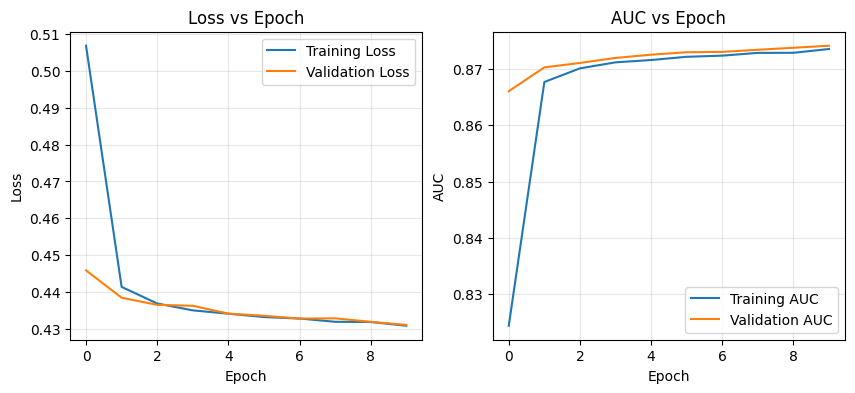

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def plot_history(history):
    keys = history.history.keys()
    auc_key = "auc" if "auc" in keys else "AUC"
    val_auc_key = "val_auc" if "val_auc" in keys else "val_AUC"

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history[auc_key], label="Training AUC")
    plt.plot(history.history[val_auc_key], label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("AUC vs Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


def make_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation="relu", input_shape=(input_dim,)))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


model_ex1 = make_model(X_Train.shape[1])

history_ex1 = model_ex1.fit(
    X_Train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history_ex1)

The training and validation curves show that the model performance improves significantly during the first few epochs. After around epoch 5–6, both the loss and AUC curves begin to flatten, indicating that the model has reached a plateau. 

The training and validation AUC values are very close to each other, and the validation loss follows a similar trend as the training loss. This suggests that the model is not overfitting. Therefore, increasing the number of epochs further is unlikely to significantly improve performance.

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [16]:
X_raw_train = np.array(Train_Sample[RawNames])
X_raw_test = np.array(Test_Sample[RawNames])

X_feat_train = np.array(Train_Sample[FeatureNames])
X_feat_test = np.array(Test_Sample[FeatureNames])

X_all_train = X_Train
X_all_test = X_Test

/home/george/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.8206 - loss: 0.5127 - val_auc: 0.8582 - val_loss: 0.4576
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8604 - loss: 0.4530 - val_auc: 0.8624 - val_loss: 0.4503
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8633 - loss: 0.4479 - val_auc: 0.8648 - val_loss: 0.4473
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8652 - loss: 0.4448 - val_auc: 0.8660 - val_loss: 0.4443
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8665 - loss: 0.4427 - val_auc: 0.8668 - val_loss: 0.4430
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8673 - loss: 0.4413 - val_auc: 0.8681 - val_loss: 0.4414
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8684 - loss: 0.4397 - val_auc: 0.8687 - val_loss: 0.4403
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.8692 - loss: 0.4384 - val_auc: 0.8694 - val_loss: 0.4394
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - a

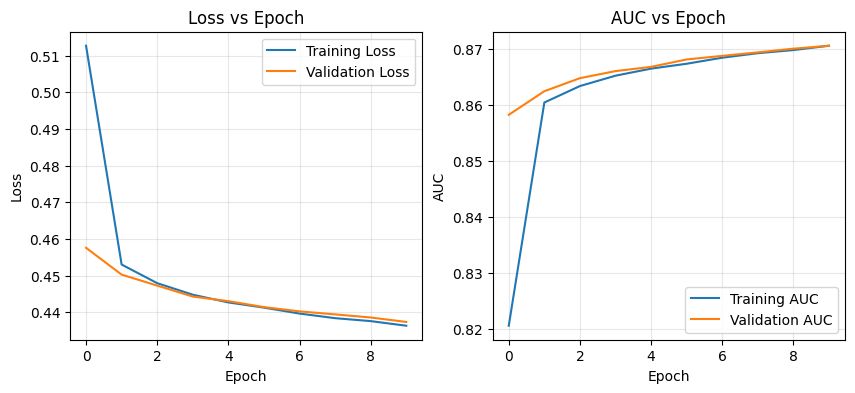

In [17]:
model_raw = make_model(X_raw_train.shape[1])
history_raw = model_raw.fit(
    X_raw_train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history_raw)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.7949 - loss: 0.5464 - val_auc: 0.8300 - val_loss: 0.5030
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8357 - loss: 0.4932 - val_auc: 0.8432 - val_loss: 0.4861
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - auc: 0.8433 - loss: 0.4809 - val_auc: 0.8471 - val_loss: 0.4764
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8470 - loss: 0.4749 - val_auc: 0.8494 - val_loss: 0.4720
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8478 - loss: 0.4729 - val_auc: 0.8506 - val_loss: 0.4692
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8496 - loss: 0.4701 - val_auc: 0.8518 - val_loss: 0.4678
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.8503 - loss: 0.4687 - val_auc: 0.8520 - val_loss: 0.4673
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc: 0.8508 - loss: 0.4677 - val_auc: 0.8525 - val_loss: 0.4667
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - au

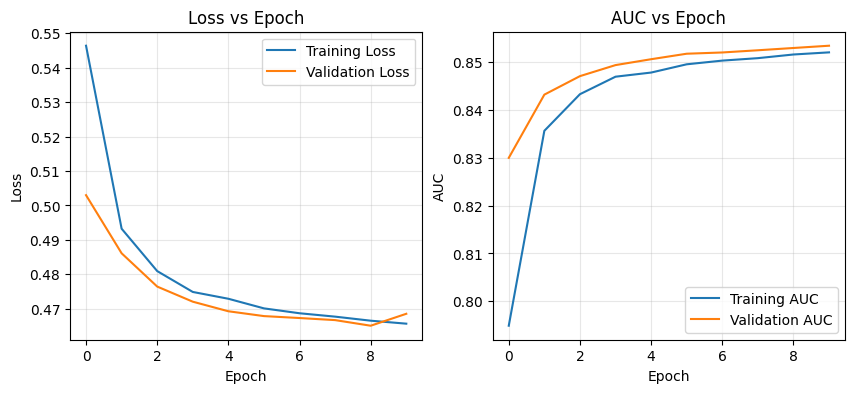

In [18]:
model_feat = make_model(X_feat_train.shape[1])
history_feat = model_feat.fit(
    X_feat_train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history_feat)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - auc: 0.8291 - loss: 0.4996 - val_auc: 0.8656 - val_loss: 0.4498
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8671 - loss: 0.4429 - val_auc: 0.8697 - val_loss: 0.4395
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.8693 - loss: 0.4384 - val_auc: 0.8709 - val_loss: 0.4378
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.8709 - loss: 0.4357 - val_auc: 0.8717 - val_loss: 0.4353
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - auc: 0.8715 - loss: 0.4346 - val_auc: 0.8724 - val_loss: 0.4343
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.8721 - loss: 0.4335 - val_auc: 0.8727 - val_loss: 0.4352
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - auc: 0.8726 - loss: 0.4326 - val_auc: 0.8728 - val_loss: 0.4333
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.8727 - loss: 0.4323 - val_auc: 0.8728 - val_loss: 0.4336
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

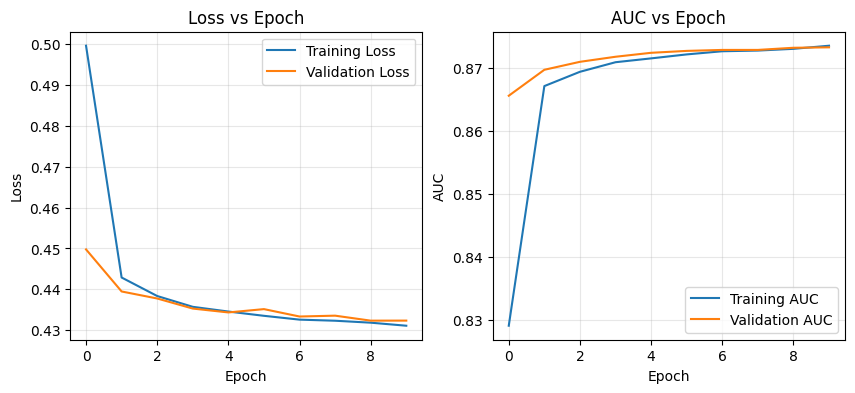

In [19]:
model_all = make_model(X_all_train.shape[1])
history_all = model_all.fit(
    X_all_train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history_all)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


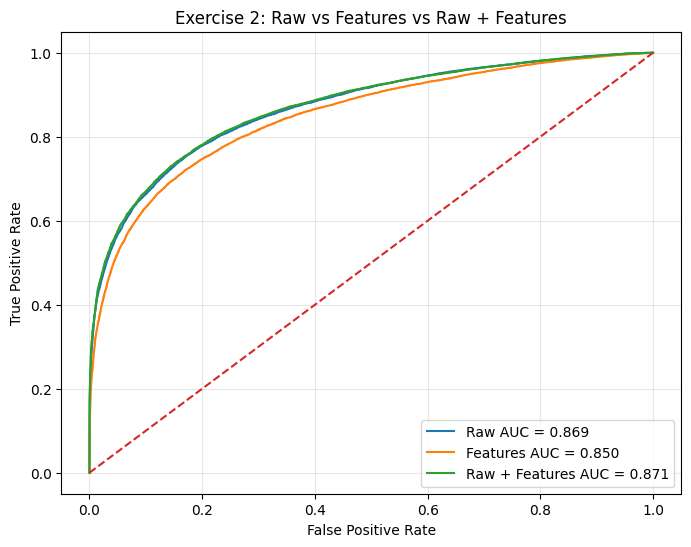

In [20]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for model, X, label in [
    (model_raw, X_raw_test, "Raw"),
    (model_feat, X_feat_test, "Features"),
    (model_all, X_all_test, "Raw + Features")
]:
    scores = model.predict(X).ravel()
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 2: Raw vs Features vs Raw + Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

/home/george/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - auc: 0.8237 - loss: 0.5056 - val_auc: 0.8651 - val_loss: 0.4478
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.8665 - loss: 0.4431 - val_auc: 0.8691 - val_loss: 0.4399
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.8695 - loss: 0.4379 - val_auc: 0.8710 - val_loss: 0.4367
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - auc: 0.8708 - loss: 0.4355 - val_auc: 0.8719 - val_loss: 0.4348
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8714 - loss: 0.4344 - val_auc: 0.8723 - val_loss: 0.4338
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.8721 - loss: 0.4333 - val_auc: 0.8726 - val_loss: 0.4334
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8724 - loss: 0.4328 - val_auc: 0.8731 - val_loss: 0.4326
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8728 - loss: 0.4321 - val_auc: 0.8730 - val_loss: 0.4327
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - 

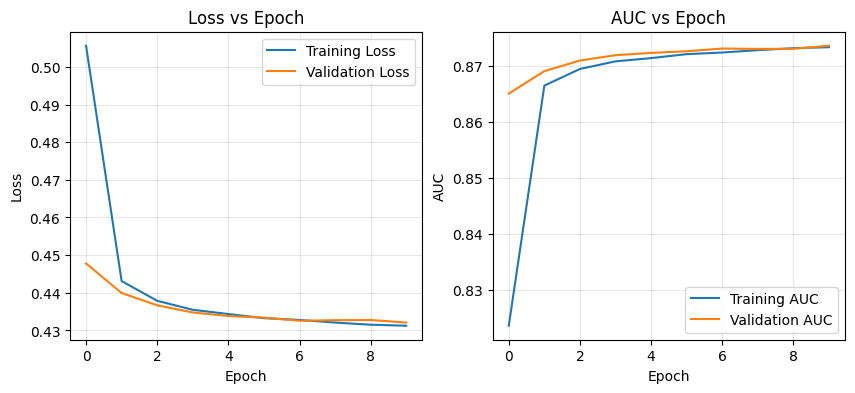

In [21]:
model1 = make_model(X_Train.shape[1])
history1 = model1.fit(
    X_Train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history1)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - AUC: 0.8505 - loss: 0.4700 - val_AUC: 0.8693 - val_loss: 0.4399
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - AUC: 0.8697 - loss: 0.4378 - val_AUC: 0.8717 - val_loss: 0.4368
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - AUC: 0.8717 - loss: 0.4343 - val_AUC: 0.8728 - val_loss: 0.4333
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - AUC: 0.8725 - loss: 0.4328 - val_AUC: 0.8735 - val_loss: 0.4332
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - AUC: 0.8730 - loss: 0.4319 - val_AUC: 0.8740 - val_loss: 0.4317
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - AUC: 0.8735 - loss: 0.4311 - val_AUC: 0.8741 - val_loss: 0.4316
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - AUC: 0.8740 - loss: 0.4304 - val_AUC: 0.8737 - val_loss: 0.4325
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.8740 - loss: 0.4303 - val_AUC: 0.8742 - val_loss: 0.4309
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/

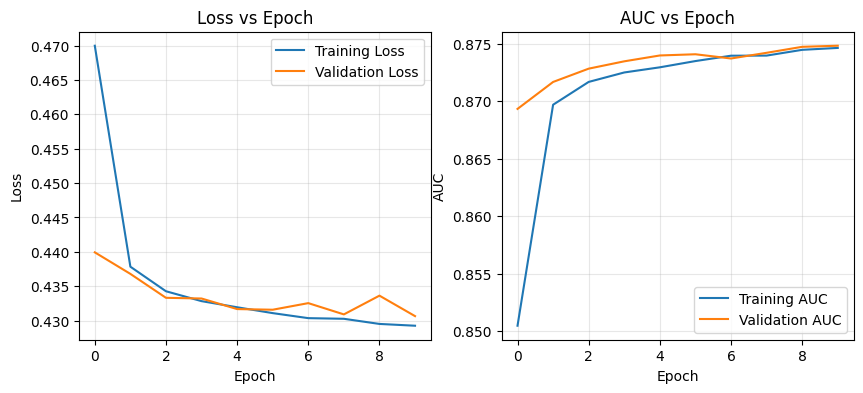

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_Train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

history2 = model2.fit(
    X_Train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history2)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - AUC: 0.8262 - loss: 0.5003 - val_AUC: 0.8683 - val_loss: 0.4423
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - AUC: 0.8624 - loss: 0.4488 - val_AUC: 0.8713 - val_loss: 0.4365
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - AUC: 0.8663 - loss: 0.4426 - val_AUC: 0.8726 - val_loss: 0.4349
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - AUC: 0.8684 - loss: 0.4393 - val_AUC: 0.8733 - val_loss: 0.4339
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - AUC: 0.8697 - loss: 0.4371 - val_AUC: 0.8736 - val_loss: 0.4324
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - AUC: 0.8705 - loss: 0.4359 - val_AUC: 0.8739 - val_loss: 0.4315
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - AUC: 0.8712 - loss: 0.4349 - val_AUC: 0.8744 - val_loss: 0.4313
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - AUC: 0.8716 - loss: 0.4342 - val_AUC: 0.8743 - val_loss: 0.4313
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms

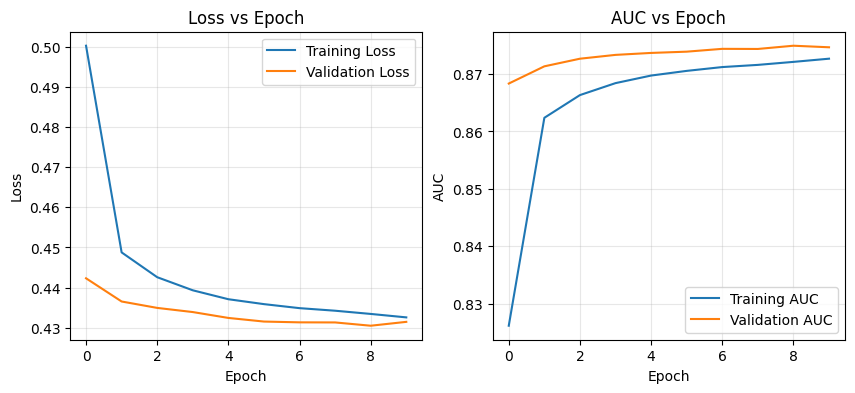

In [23]:
model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_Train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

history3 = model3.fit(
    X_Train,
    y_Train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

plot_history(history3)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


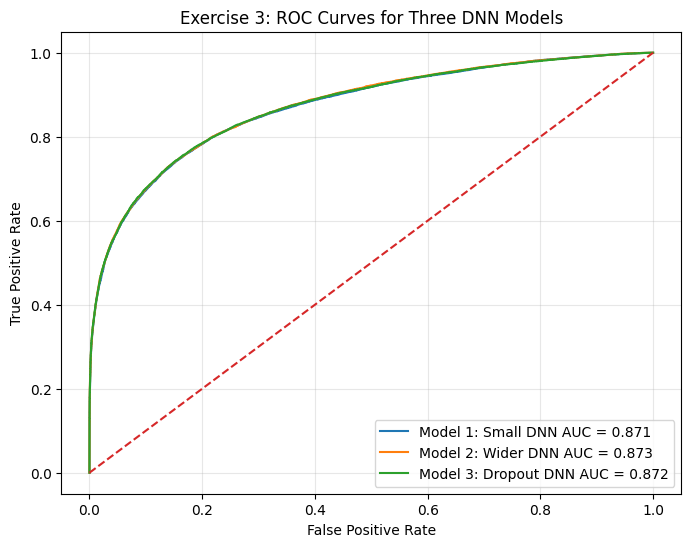

,DNN Model,Test AUC
0,Model 2: Wider DNN,0.873041
1,Model 3: Dropout DNN,0.872477
2,Model 1: Small DNN,0.871424


In [24]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

dnn_results = []

for model, label in [
    (model1, "Model 1: Small DNN"),
    (model2, "Model 2: Wider DNN"),
    (model3, "Model 3: Dropout DNN")
]:
    scores = model.predict(X_Test).ravel()
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    dnn_results.append([label, roc_auc])
    plt.plot(fpr, tpr, label=f"{label} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 3: ROC Curves for Three DNN Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

dnn_result_df = pd.DataFrame(dnn_results, columns=["DNN Model", "Test AUC"])
dnn_result_df = dnn_result_df.sort_values("Test AUC", ascending=False).reset_index(drop=True)
dnn_result_df

In [25]:
best_dnn_name = dnn_result_df.loc[0, "DNN Model"]

if best_dnn_name == "Model 1: Small DNN":
    best_dnn_model = model1
elif best_dnn_name == "Model 2: Wider DNN":
    best_dnn_model = model2
else:
    best_dnn_model = model3

print("Best DNN:", best_dnn_name)
print("Best DNN Test AUC:", dnn_result_df.loc[0, "Test AUC"])

Best DNN: Model 2: Wider DNN
Best DNN Test AUC: 0.8730409961853715


I trained three different Keras DNN models. Model 1 is a smaller baseline model, Model 2 is wider with more hidden units, and Model 3 is deeper and includes dropout to reduce overfitting. I compared the models using ROC curves and test AUC values. The best DNN was selected based on the highest test AUC, while also checking the training history plots to make sure the model was not clearly overfitting.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [26]:
best_dnn_model
best_dnn_name

'Model 2: Wider DNN'

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


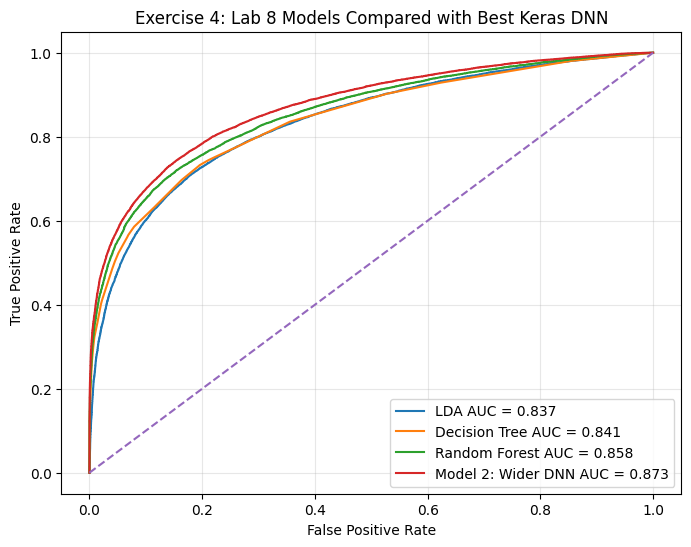

,Model,Test AUC
0,Model 2: Wider DNN,0.873041
1,Random Forest,0.857803
2,Decision Tree,0.840678
3,LDA,0.836632


In [27]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

lab8_models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
}

results = []

plt.figure(figsize=(8, 6))

for name, model in lab8_models.items():
    model.fit(X_Train, y_Train)
    scores = model.predict_proba(X_Test)[:, 1]

    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    results.append([name, roc_auc])
    plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")

dnn_scores = best_dnn_model.predict(X_Test).ravel()
fpr, tpr, _ = roc_curve(y_Test, dnn_scores)
dnn_auc = auc(fpr, tpr)

results.append([best_dnn_name, dnn_auc])
plt.plot(fpr, tpr, label=f"{best_dnn_name} AUC = {dnn_auc:.3f}")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 4: Lab 8 Models Compared with Best Keras DNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

result_df = pd.DataFrame(results, columns=["Model", "Test AUC"])
result_df = result_df.sort_values("Test AUC", ascending=False).reset_index(drop=True)
result_df

For Exercise 4, I repeated the Lab 8 Exercise 4 comparison using the same classifiers: LDA, Decision Tree, and Random Forest. Then I added the best Keras DNN from Exercise 3 to the same ROC/AUC comparison. This gives a fair comparison because all models are evaluated on the same test sample using the same metric, test AUC. The best overall model is the one with the highest test AUC in the final table.